### Ejemplos con datos de cuencas sobre la regresión logística

In [1]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

# Cargar datos
gdf = gpd.read_file("df_catchments_spatial.gpkg")

# Preparar datos para regresión logística
gdf['landslide'] = np.where(gdf['lands_rec'] >= 1, 1, 0)
var = ['area', 'elev_mean', 'rel_mean']
y = gdf['landslide']

# Escalar variables independientes
st = StandardScaler()
X_scaled = st.fit_transform(gdf[var])

# Añadir una constante para el término de intercepción
X = sm.add_constant(X_scaled)

# Entrenar el modelo de regresión logística
model = sm.Logit(y, X).fit()

# Imprimir un resumen del modelo de regresión logística
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.377649
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              landslide   No. Observations:                  526
Model:                          Logit   Df Residuals:                      522
Method:                           MLE   Df Model:                            3
Date:                Mon, 08 Jun 2026   Pseudo R-squ.:                  0.3566
Time:                        19:07:37   Log-Likelihood:                -198.64
converged:                       True   LL-Null:                       -308.74
Covariance Type:            nonrobust   LLR p-value:                 1.815e-47
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6657      0.162     10.271      0.000       1.348       1.984
x1             0.5881      0.

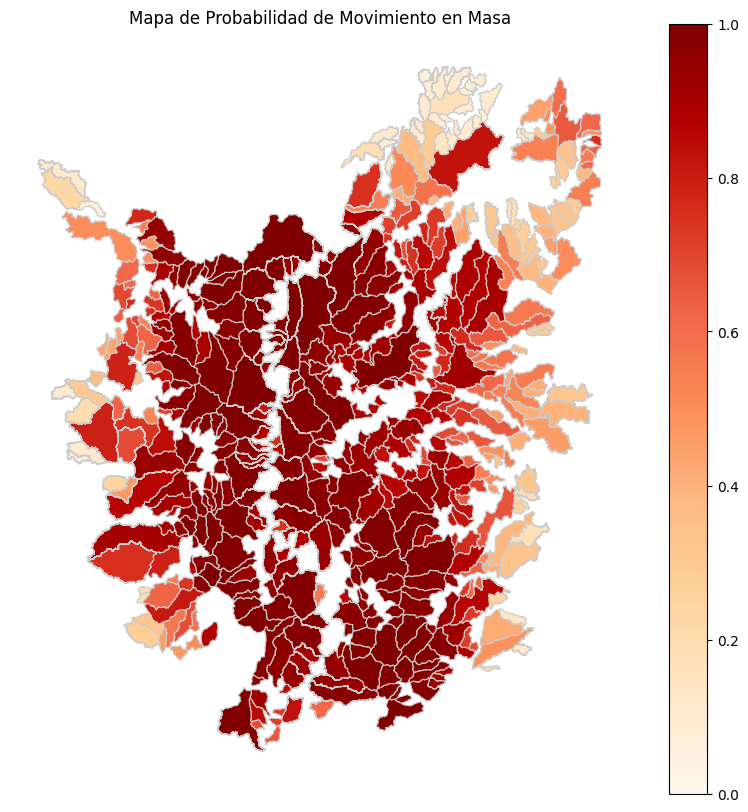

In [2]:
# Obtener las predicciones en términos de probabilidad
y_prob = model.predict(X)

# Añadir las probabilidades de predicción al GeoDataFrame
gdf['probability_landslide'] = y_prob

# Graficar el mapa con las probabilidades de predicción
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='probability_landslide', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True, vmin=0, vmax=1)
ax.set_title('Mapa de Probabilidad de Movimiento en Masa')
ax.set_axis_off()
plt.show()

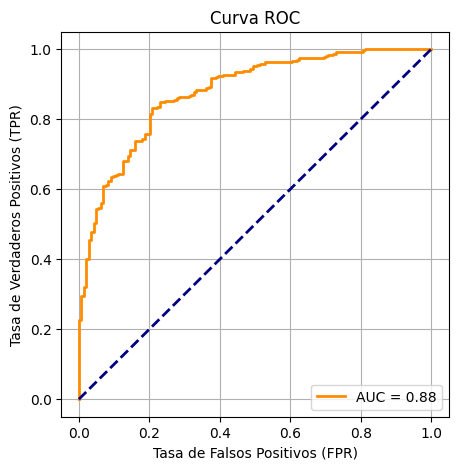

In [3]:
# Calcular la curva ROC y el AUC
fpr, tpr, thresholds = roc_curve(y, y_prob)
auc = roc_auc_score(y, y_prob)

# Graficar la curva ROC
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()